In [6]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))  # project root for gates
os.chdir(os.path.abspath(".."))  # data/ paths resolve from project root
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
from gates.plotting import plot_fp_predictions

In [45]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
import pandas as pd


In [38]:
preds = xr.open_dataset("/mnt/shared/home/kr21883/GATES_LPDM_emulator/model_test_predictions/brazil_model/BRAZIL_proper/predictions_BRAZIL/predictions_2014_01.nc")

[1, 1]


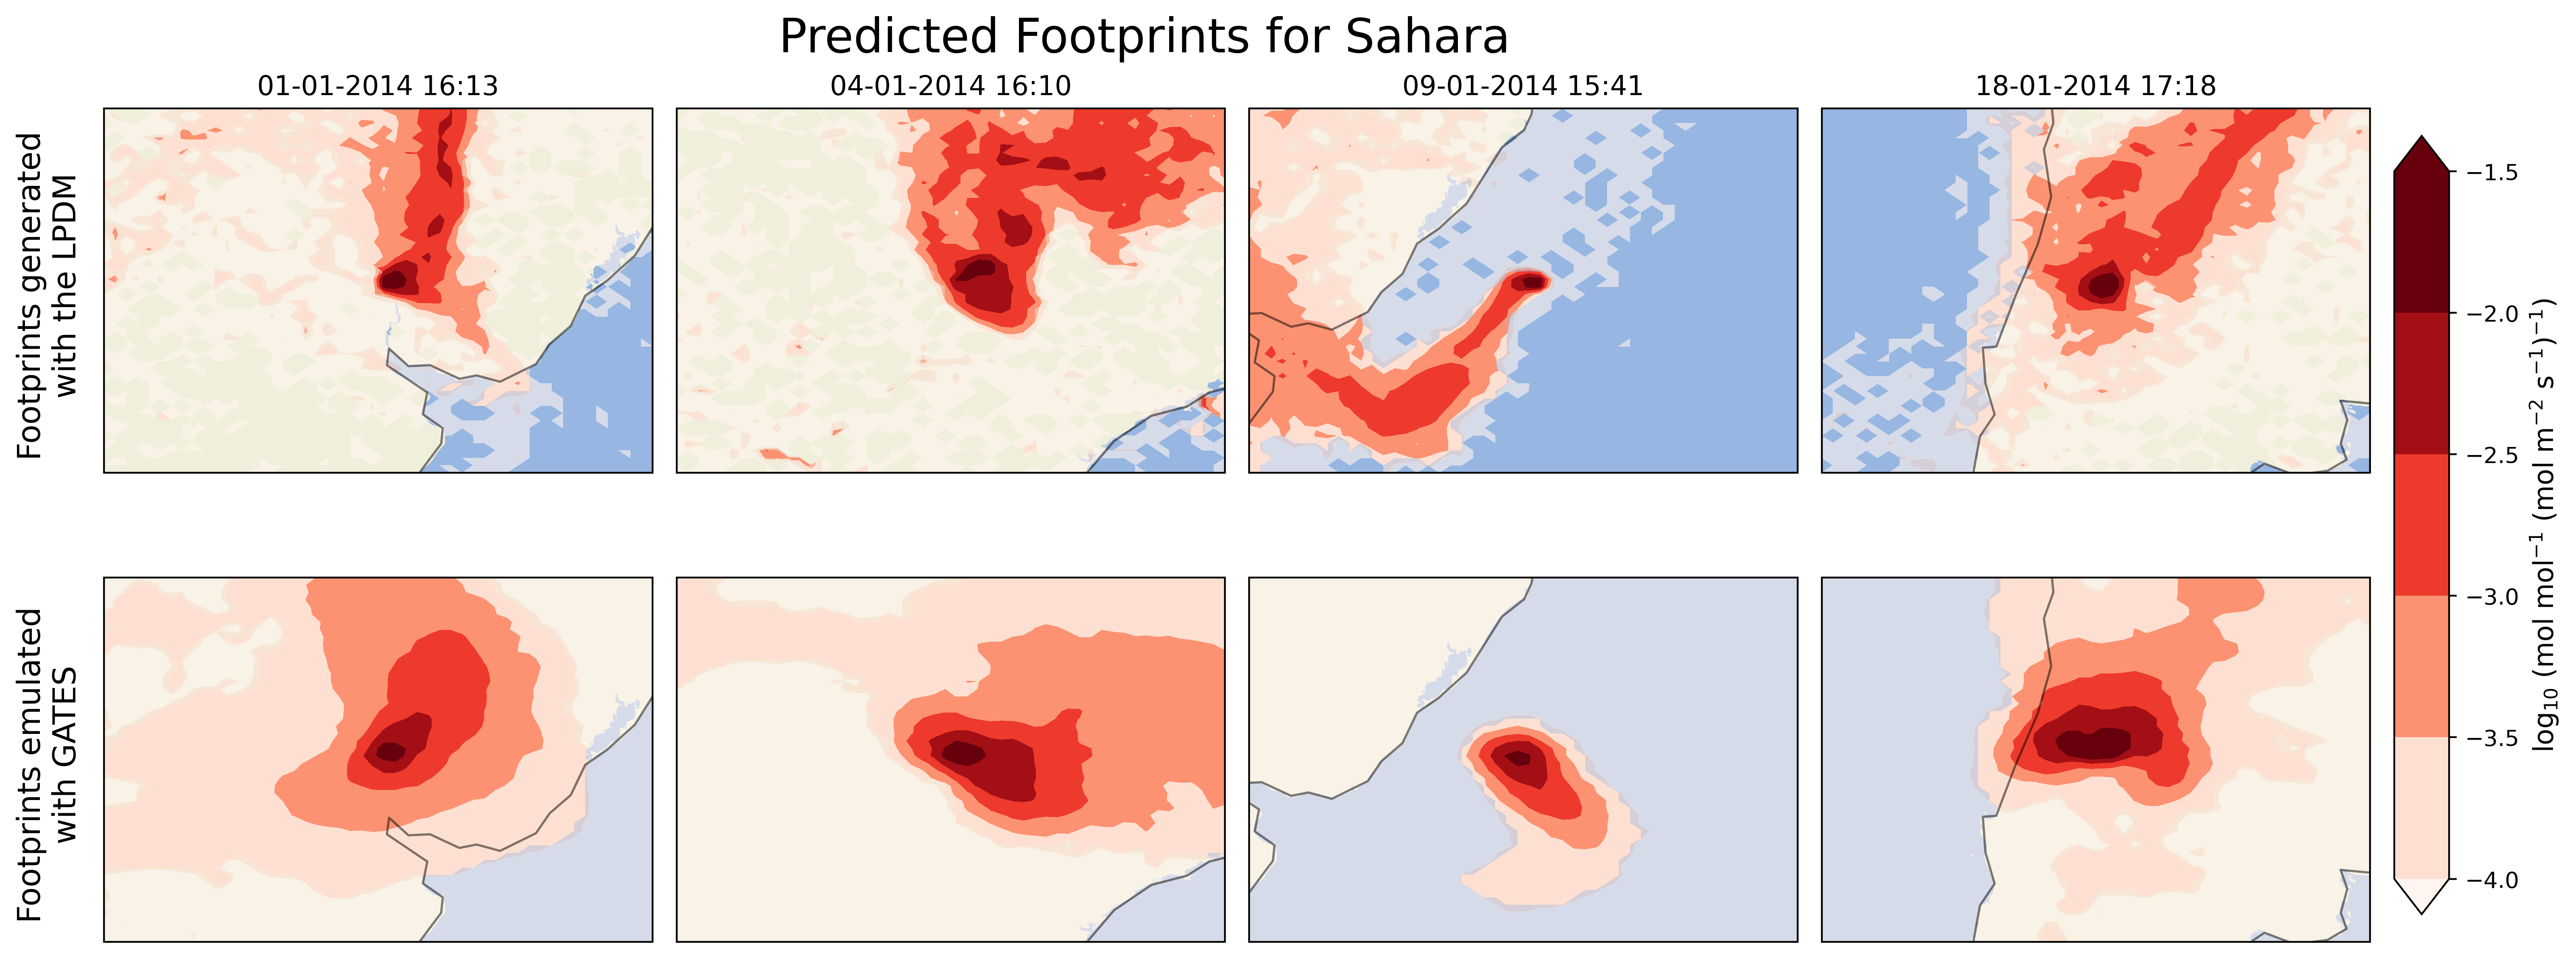

In [39]:
## plot footprints with this function. specify the index of the footprints to plot as a list in idxs_list (the length can be variable). Contour is recommended, you can override the levels and the min/max with levels and vmin_vmax arguments. The threshold parameter is used in the contour - anything below the threshold is set as a lighter, see-through colour. 
plot_fp_predictions(preds, idxs_list=[10, 100, 300, 800], contour=True, thres=1e-4, fig_title="Predicted Footprints for Sahara", which_dataspace="original")

In [13]:
from gates.data.load_data import load_flux_data, cut_flux_data
from gates.evaluation.post_processing import threshold_fps
import gates.evaluation.metrics as gates_metrics

In [42]:
# threshold the predicted footprints to a determined threshold  
preds = threshold_fps(preds, threshold=1.75e-5)

[1, 1]


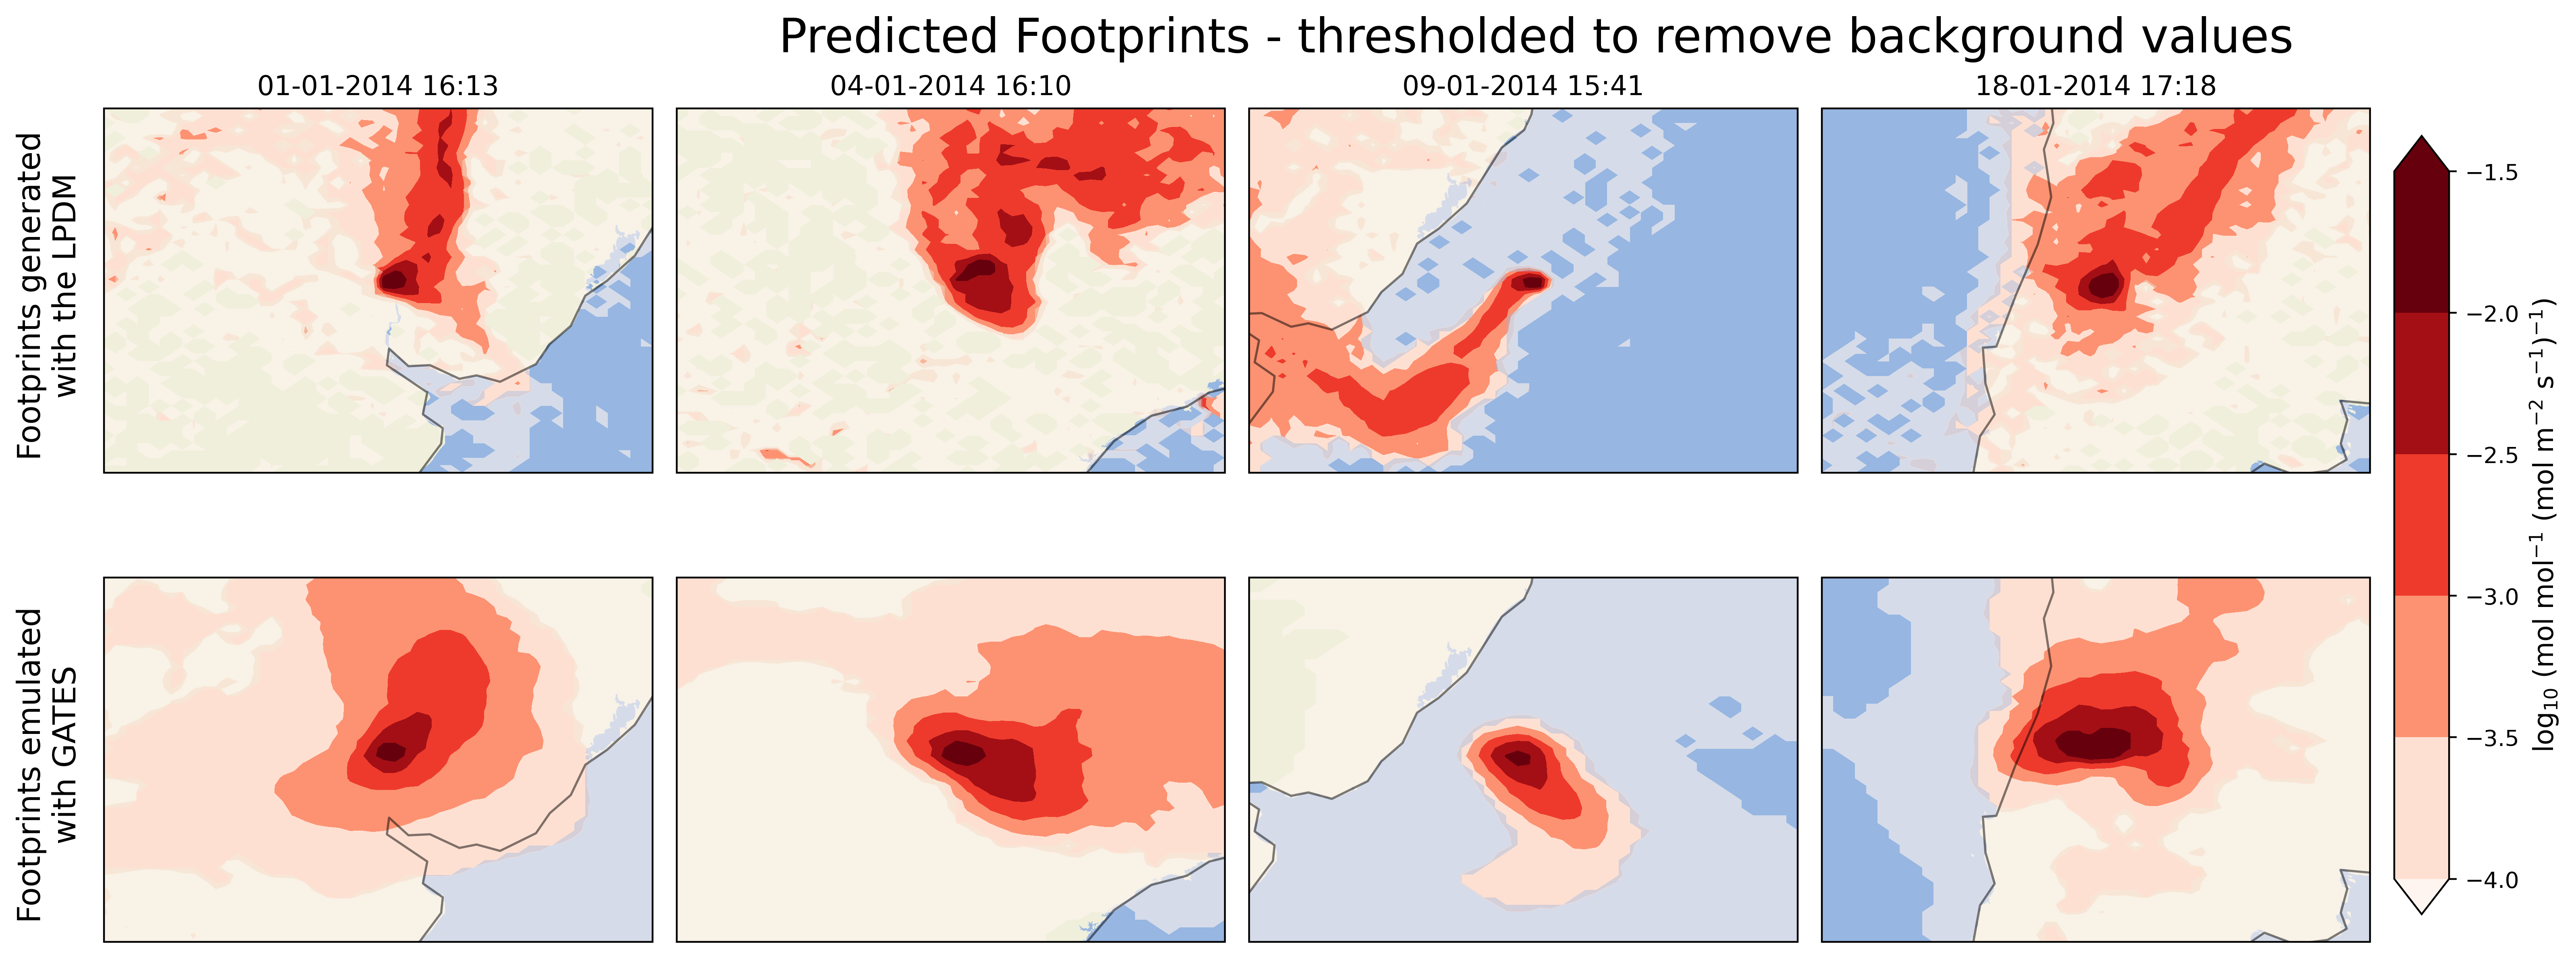

In [18]:
# and plot them
plot_fp_predictions(preds, idxs_list=[10, 100, 300, 800], contour=True, thres=1e-4, fig_title="Predicted Footprints - thresholded to remove background values", which_dataspace="thresholded")

In [43]:
# you can plot some stats about the footprints with
gates_metrics.compute_footprint_metrics(preds["fp_original"], preds["fp_pred_thres"], ignore_mask=preds["fp_nan_mask"])

{'iou': 0.5380205418750177,
 'mse': 6.886634196234809e-07,
 'mae': 0.00021187351376283914,
 'nmae': 0.998929500579834,
 'corrcoef': 0.6466415184770269,
 'corrcoef_log': 0.5953290808586513,
 'bias': -4.610755786416121e-05}

In [32]:
import gates

In [20]:
# you can also load the fluxes, crop them and calculate the mole fractions
ems = load_flux_data("NORTHAFRICA", year=2016)
cropped_fluxes, _ = cut_flux_data(ems, preds, size=50)
mfs = gates_metrics.calculate_mfs(preds[["fp_original", "fp_pred_thres"]], cropped_fluxes, transform_factor=1e9)

ValueError: Flux file not found for domain 'NORTHAFRICA', species 'ch4' and year '2016' 
at data/fluxes_archive/NORTHAFRICA/ch4_NORTHAFRICA_2016.nc. 
The existing files are: []

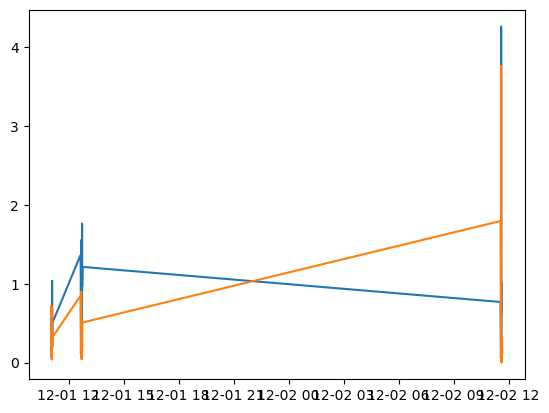

In [61]:
# we can plot these (new functions coming)
plt.plot(mfs["mf_original"].isel(time=slice(0,100)).time, mfs["mf_original"].isel(time=slice(0,100)))
plt.plot(mfs["mf_pred_thres"].isel(time=slice(0,100)).time, mfs["mf_pred_thres"].isel(time=slice(0,100)))

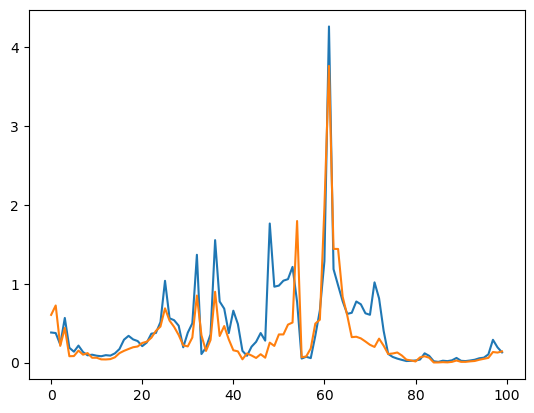

In [ ]:
# we can plot these (new functions coming)
plt.plot(mfs["mf_original"].isel(time=slice(0,100)).values)
plt.plot(mfs["mf_pred_thres"].isel(time=slice(0,100)).values)

In [45]:
# and get some metrics
gates_metrics.compute_mfs_metrics(mfs["mf_original"], mfs["mf_pred_thres"])

{'corrcoef': 0.7997281586305034,
 'mae': 0.3363400995731354,
 'mean_bias': -0.2613910138607025,
 'true_mean': 0.7008071541786194,
 'predicted_mean': 0.4394161105155945,
 'r2_score': 0.5422990322113037}

In [ ]:
# and compute metrics using uniform fluxes
gates_metrics.compute_static_mf_metrics(preds["fp_original"], preds["fp_pred_thres"], ignore_mask=preds["fp_nan_mask"])

{'uniform': {'corrcoef': 0.662377000764233,
  'mae': 0.20506483234041042,
  'mean_bias': -0.1930486263981564,
  'true_mean': 0.5005686759948731,
  'predicted_mean': 0.30752004959671664,
  'r2_score': -0.1495677476362991},
 'checkerboard': {'corrcoef': 0.6641080550544338,
  'mae': 0.10131603726918854,
  'mean_bias': -0.09510897798840574,
  'true_mean': 0.24953370094299315,
  'predicted_mean': 0.15442472295458742,
  'r2_score': -0.1299293924477385},
 'checkerboard_10': {'corrcoef': 0.5879137280236607,
  'mae': 0.1045702502375363,
  'mean_bias': -0.09873520504572611,
  'true_mean': 0.22677549123764038,
  'predicted_mean': 0.12804028619191427,
  'r2_score': -0.29310108975733895},
 'checkerboard_25': {'corrcoef': 0.740069475387015,
  'mae': 0.09323803794650871,
  'mean_bias': -0.07748282112802088,
  'true_mean': 0.1912314236164093,
  'predicted_mean': 0.11374860248838843,
  'r2_score': 0.31260759760973933}}

## plotting sample predictions

# this is a bit hacky, but you can visualise sample predictions generated during model training as follows

In [21]:
preds = xr.open_dataset("/mnt/shared/home/kr21883/GATES_LPDM_emulator/model_test_predictions/brazil_model/BRAZIL_proper/predictions_BRAZIL/predictions_2014_01.nc")

In [22]:
from gates.config import get_config
from gates.data.load_data import load_fps, cut_satellite_data
cfg = get_config()


In [23]:
# load the footprints for the same time period as the predictions, and crop them to the same spatial extent (this is needed to get the lat/lon coordinates for plotting)
fps = load_fps(cfg.fp_datadir / "BRAZIL" / "GOSAT*2012*", verbose=True)
fps_subset = fps.sel(time=preds.time)
fps_cropped = cut_satellite_data(fps_subset, size=50)[0]
# then extract the lat/lon coordinates for the cropped area, needed for plotting
preds["lat_coords"] = fps_cropped["lat_coords"]
preds["lon_coords"] = fps_cropped["lon_coords"]

WITH CHUNKING -
there was an error opening the dataset. checking if any of the files are in the bad files list
There was a problem opening files!! compared against the list of known bad files and couldnt find a match
check if there has been a problem, or maybe a new bad file needs to be added to the list!


ValueError: Specified directory does not exist:
 data/fp_archive/BRAZIL/GOSAT*2012*

[1, 1]


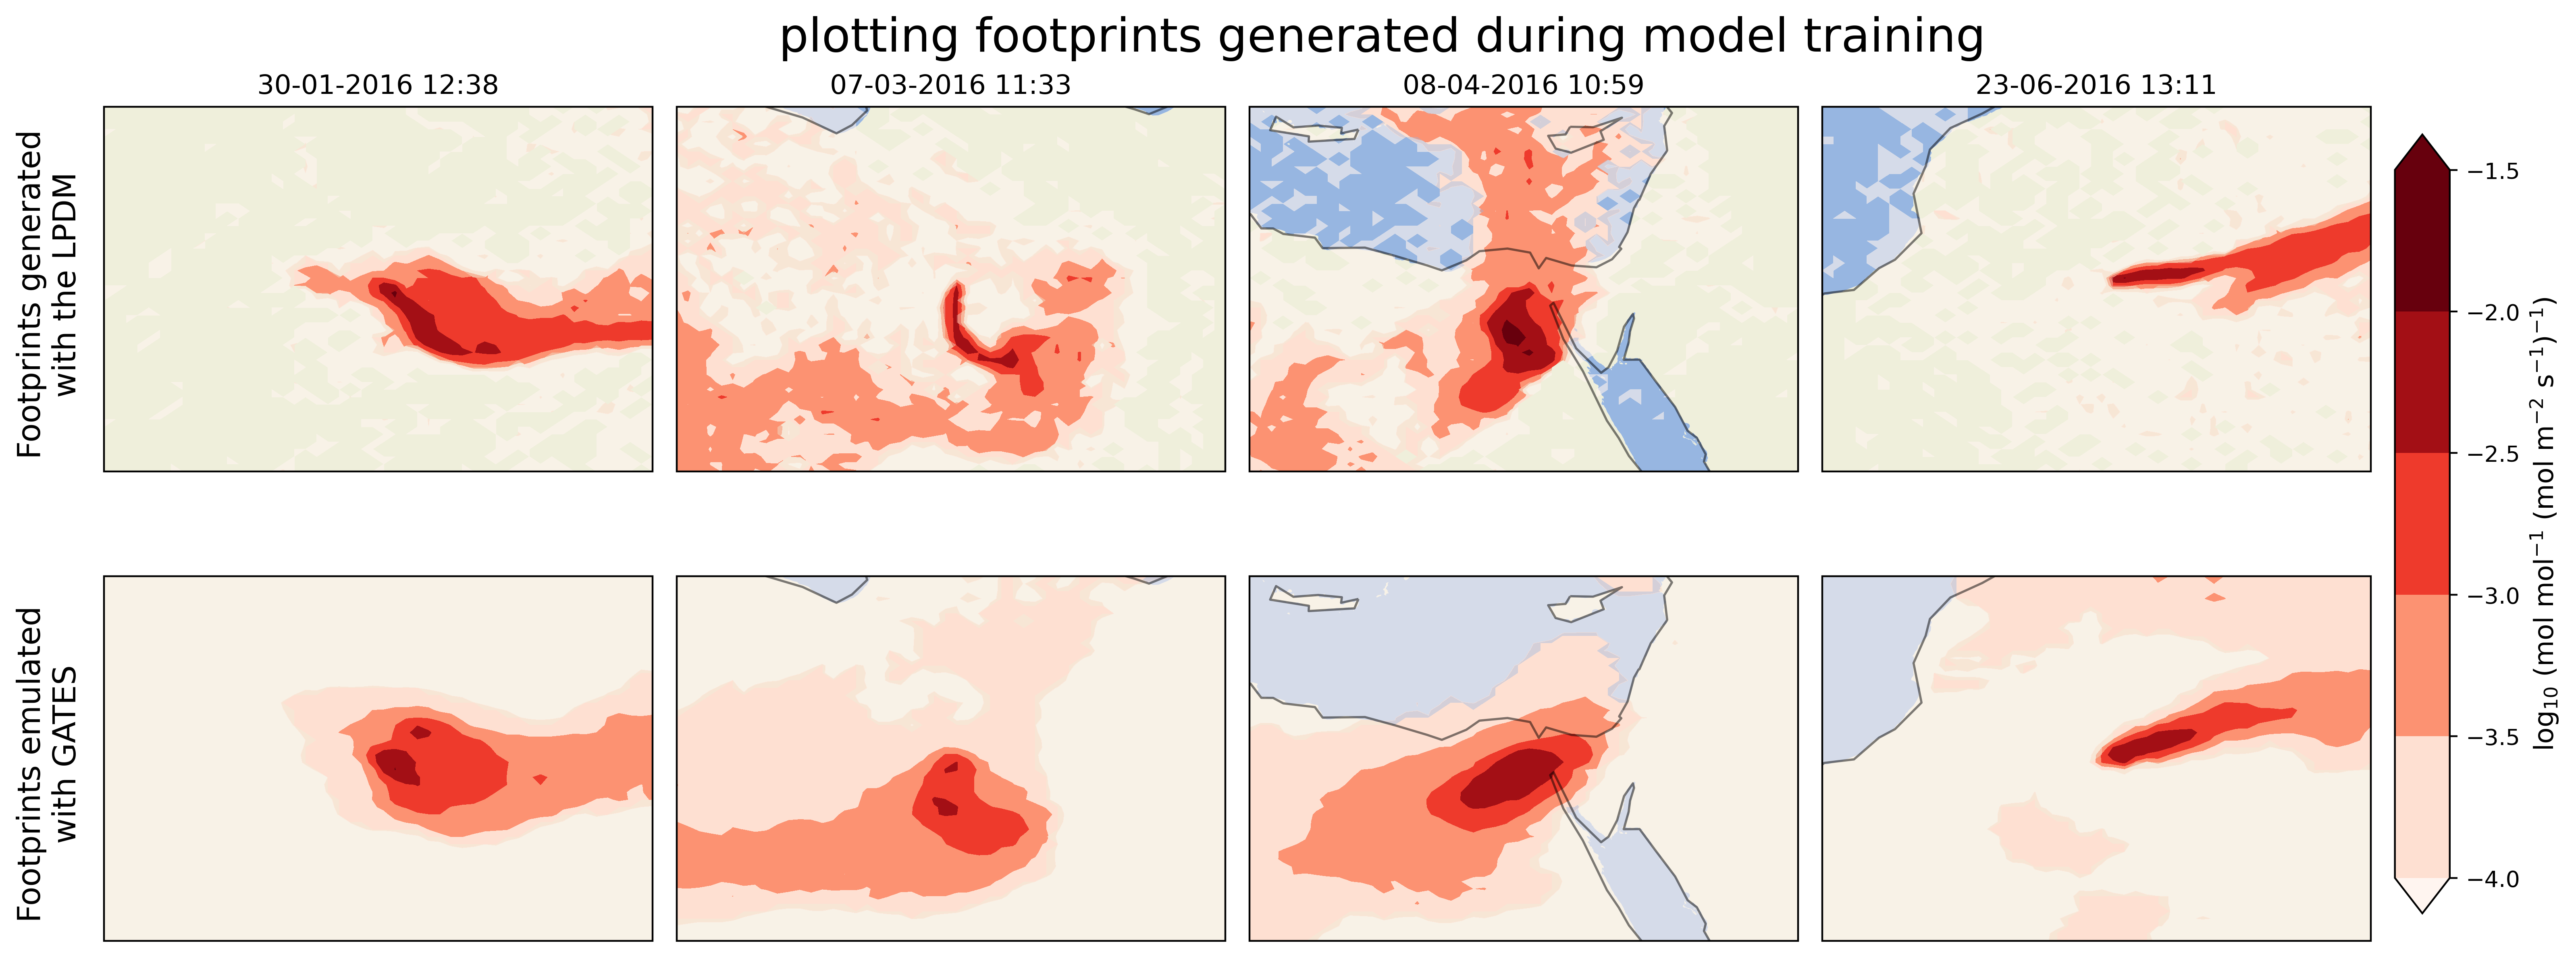

In [ ]:
# now you can plot
plot_fp_predictions(preds, idxs_list=[10, 23, 33, 56], contour=True, thres=1e-4, fig_title="plotting footprints generated during model training", which_dataspace="original")

## across region

In [ ]:
preds = xr.open_dataset("/mnt/shared/home/kr21883/GATES_LPDM_emulator/model_test_predictions/brazil_model/BRAZIL_proper/predictions_INDIA/predictions_2014_01.nc")
preds = threshold_fps(preds, threshold=1.75e-5)

[1, 1]


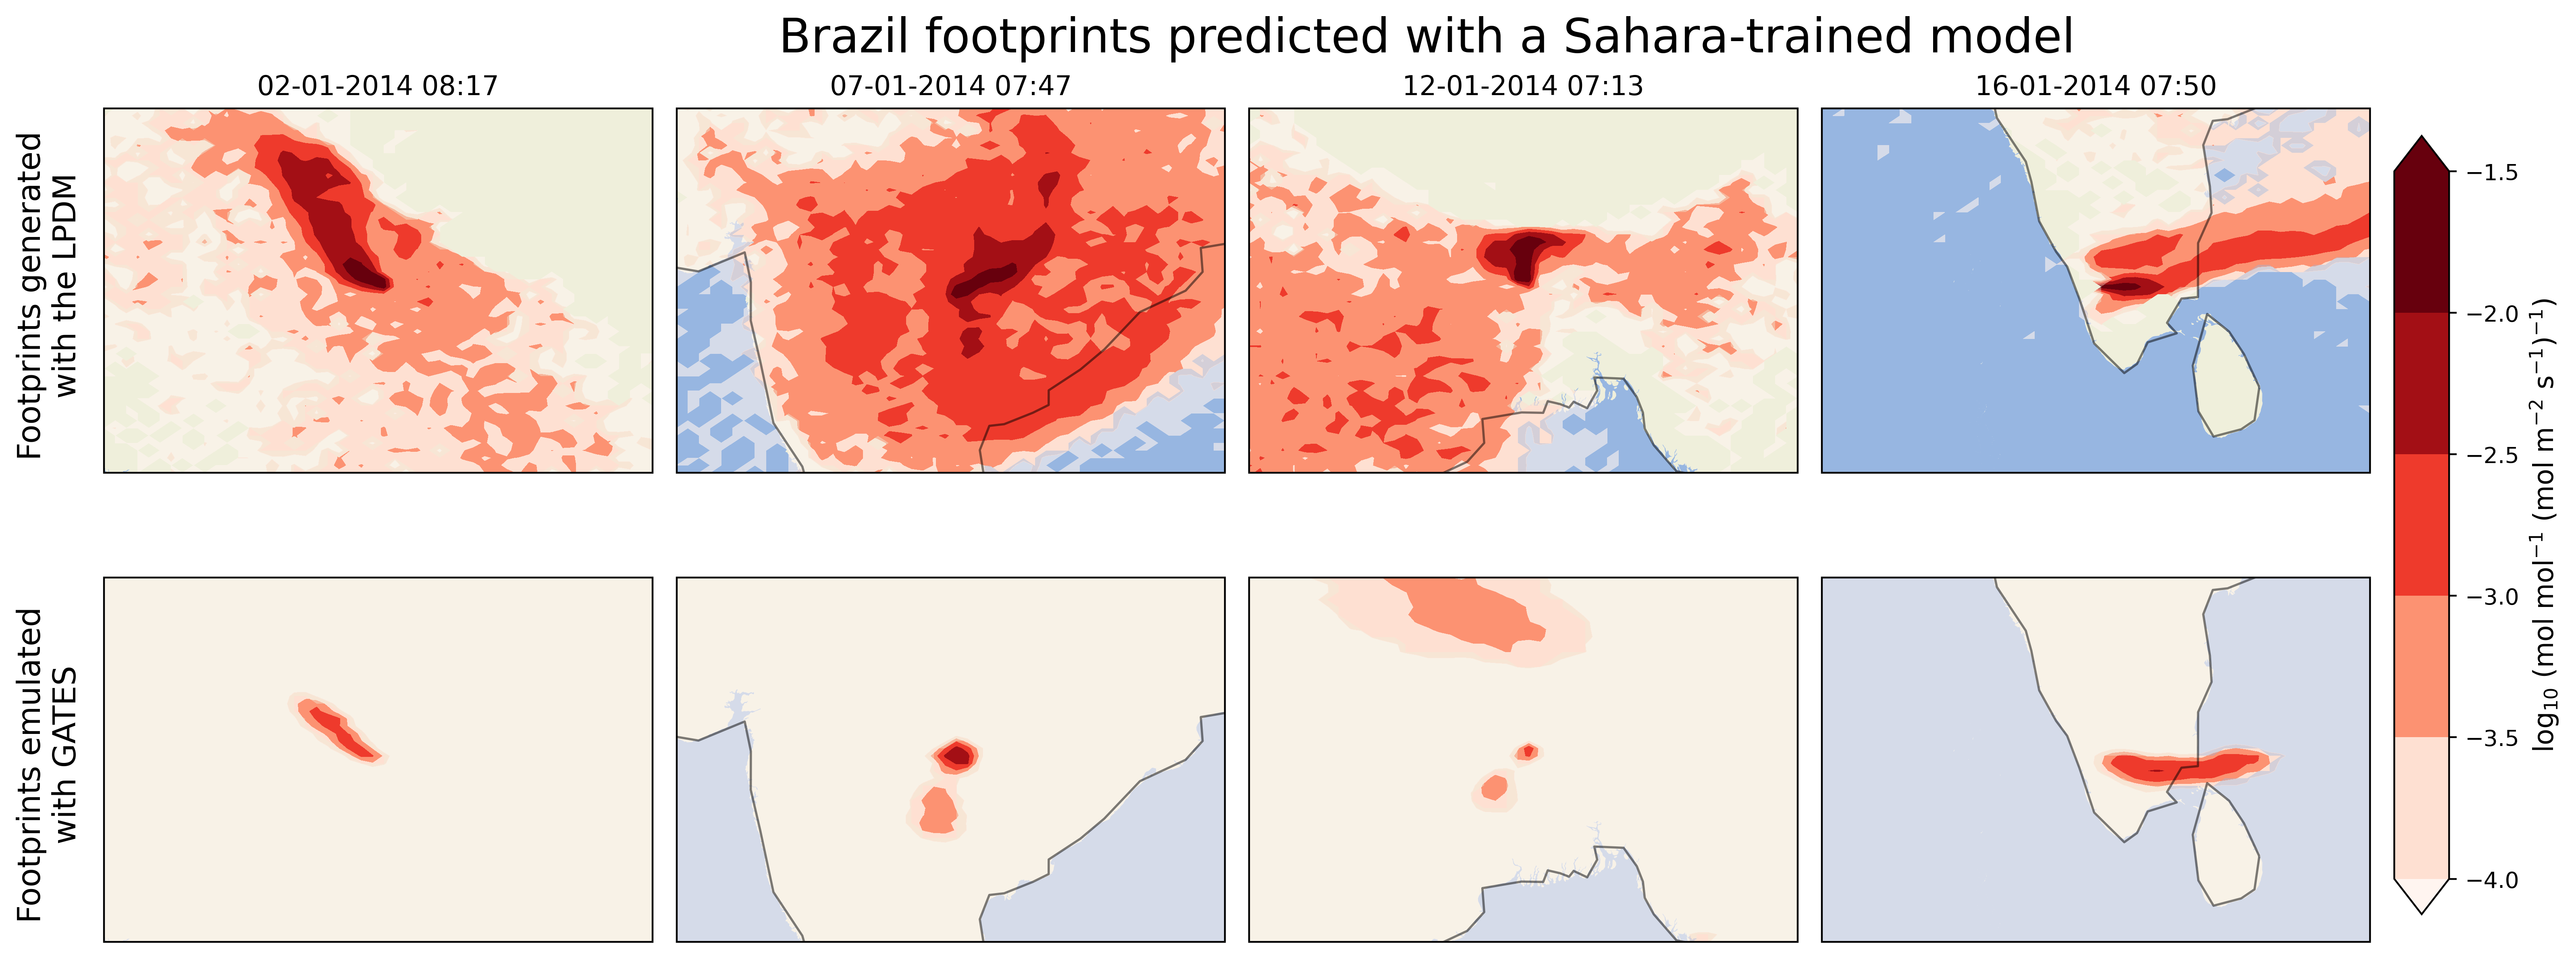

In [30]:
# and plot them
plot_fp_predictions(preds, idxs_list=[10, 100, 200, 300], contour=True, thres=1e-4, fig_title="Brazil footprints predicted with a Sahara-trained model", which_dataspace="original")

# Metrics for whole test set year

In [ ]:
# Point to your predictions folder
pred_dir = "model_test_predictions/china_model/CHINA_proper/predictions_CHINA"

all_results = []

for path in sorted(glob.glob(f"{pred_dir}/predictions_2014_*.nc")):
    print(path)
    preds = xr.open_dataset(path)
    preds = threshold_fps(preds, threshold=1.75e-5)
    metrics = gates_metrics.compute_footprint_metrics(
        preds["fp_original"],
        preds["fp_pred_thres"],
        ignore_mask=preds["fp_nan_mask"]
    )
    month = path.split("_")[-1].replace(".nc", "")  # e.g. "01"
    metrics["month"] = month
    all_results.append(metrics)
    print(f"2014-{month}: {metrics}")

# Summarise as a DataFrame
df = pd.DataFrame(all_results).set_index("month")
print("\n=== Full year summary ===")
print(df)
print("\n=== Annual mean ===")
print(df.drop(columns=["month"], errors="ignore").mean())

out_path = f"{pred_dir}/metrics_summary.txt"
with open(out_path, "w") as f:
    f.write("=== Per-month metrics ===\n")
    f.write(df.to_string())
    f.write("\n\n=== Annual mean ===\n")
    f.write(df.mean().to_string())
print(f"Saved to {out_path}")

model_test_predictions/brazil_model/BRAZIL_proper/predictions_INDIA/predictions_2014_01.nc
2014-01: {'iou': 0.3098515481132601, 'mse': 3.1140821192821022e-06, 'mae': 0.0004504722310230136, 'nmae': 1.0833492279052734, 'corrcoef': 0.2304757556964466, 'corrcoef_log': 0.23697041251153003, 'bias': -0.0003982357739005238, 'month': '01'}
model_test_predictions/brazil_model/BRAZIL_proper/predictions_INDIA/predictions_2014_02.nc
2014-02: {'iou': 0.30826383045052347, 'mse': 2.462111524437205e-06, 'mae': 0.0003849618951790035, 'nmae': 1.0325782299041748, 'corrcoef': 0.2532870849689243, 'corrcoef_log': 0.22200685335137185, 'bias': -0.0003476568963378668, 'month': '02'}
model_test_predictions/brazil_model/BRAZIL_proper/predictions_INDIA/predictions_2014_03.nc
2014-03: {'iou': 0.3244199321152482, 'mse': 2.7712123937817523e-06, 'mae': 0.00038255221443250775, 'nmae': 1.0479053258895874, 'corrcoef': 0.32195752846915265, 'corrcoef_log': 0.22967230038573178, 'bias': -0.0003350218466948718, 'month': '03'}